### Agentic RAG
🤖 What is Agentic RAG?

Agentic RAG stands for Agentic Retrieval-Augmented Generation — an advanced version of RAG where instead of a static, one-shot LLM response,the system uses an agent that:

- reasons,
- plans,
- retrieves,
- uses tools,
- and even retries or reflects
to generate better, more grounded answers.

In [4]:
import os
from typing import List, Annotated
from pydantic import BaseModel

## Load required libraries and modules
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langgraph.graph import StateGraph, END

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model(model="openai/gpt-oss-120b", model_provider="groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.1'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002F2C02A4410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002F2C02A4E10>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
## Document Preprocessing
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())

## Recursive character text splitters and vectorstore
splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50)
split_docs = splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(split_docs, embeddings)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [6]:
retriever.invoke("What are agents?")

[Document(id='718bae1e-3039-4517-837c-77b5003858f3', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [8]:
## Define RAG State
class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

In [9]:
## LangGraph Nodes
def retrieve_docs(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question = state.question, retrieved_docs = docs)

def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)

    return RAGState(question = state.question, retrieved_docs = state.retrieved_docs, answer = response.content)

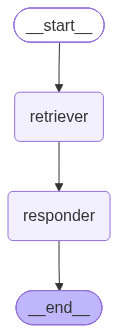

In [10]:
## Build LangGraph
builder = StateGraph(RAGState)

## Add Nodes
builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

## Add edges
builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [12]:
## Run the Agentic RAG

if __name__ == "__main__":
    user_question = input()
    initial_state = RAGState(question=user_question)
    final_state = graph.invoke(initial_state)

    print("\n✅ Final Answer:\n", final_state['answer'])


✅ Final Answer:
 ### What an AI agent is  

An **AI (artificial‑intelligence) agent** is a software system that can perceive its environment, reason about what to do, and then act to achieve a goal.  In modern practice many of these agents are built around a **large language model (LLM)** that serves as the “brain” for reasoning and decision‑making, while other components supply perception, memory, and the ability to execute concrete actions.

---

## Core ingredients of a modern LLM‑powered autonomous agent  

| Component | Role | Typical implementation |
|-----------|------|------------------------|
| **LLM (brain)** | Generates natural‑language plans, interprets instructions, does chain‑of‑thought reasoning. | GPT‑4, Claude, Llama‑2, etc. |
| **Perception / Input** | Feeds the agent information about the world (text, web pages, sensor data, code output). | Web‑search APIs, file loaders, OCR, code execution sandbox. |
| **Memory / State** | Stores short‑term context (the current con

In [13]:
final_state

{'question': 'Tell me about AI agents and how they work.',
 'retrieved_docs': [Document(id='8d6ae604-640b-4f44-bb3d-e86934d2f935', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflec